In [1]:
import numpy as np
import matplotlib

from itertools import combinations, chain
from scipy.integrate import solve_ivp

from matplotlib import pyplot as plt
from model import Model

from PIL import Image

matplotlib.rcParams["text.usetex"] = True
#matplotlib.rcParams["text.latex.preamble"].append(r"\usepackage{xfrac}")
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{xfrac}"

In [2]:

class Model:
	'''
	The Model class is used to define an adaptive dynamics simulation
	based on the same system of equations in the discrete random loci
	model. We use a numerical adaptive dynamics approach, where the
	cost function can be defined by defining the b and res vectors.
	'''

	def __init__(self, **kwargs):
		self.H_alleles = 100 #number of alleles
		self.P_alleles = 100 #number of alleles
		self.N_iter = 100 #number of evolutionary time steps

		self.mode = 'coevol' 	#Can be set to coevol, path, or host

		#Set default parameters and resistance-cost curve
		self.b = 1
		self.mu = 0.2			#Death rate
		self.k = 0.001			#Coefficient of density-dependent growth
		self.beta_j = 0.001		#Baseline density-dependent transmission rate for junveniles
		self.beta_a = 1			#Baseline frequency-dependent transmission rate for adults
		self.m = 0.5			#Maturation rate

		for key, value in kwargs.items():
			setattr(self, key, value)

		self.resJ = np.logspace(-1, 1, self.H_alleles, base=3)
		self.infJ = np.logspace(-1, 1, self.P_alleles, base=3)
		self.resA = 1/self.resJ
		self.infA = 1/self.infJ
		self.infJ *= self.beta_j
		self.infA *= self.beta_a

	def mutation(self, genotypes, mut=0.05):
		N_alleles = len(genotypes)

		M = np.diag(np.full(N_alleles, 1 - mut))
		M = M + np.diag(np.ones(N_alleles - 1)*mut/2, 1)
		M = M + np.diag(np.ones(N_alleles - 1)*mut/2, -1)
		M[0,1] = mut
		M[N_alleles - 1, N_alleles - 2] = mut

		return np.dot(M, genotypes)

	#Define the dynamical system	
	def df(self, t, X):
		Sj = X[:self.H_alleles]
		Sa = X[self.H_alleles:2*self.H_alleles] 
		Ij = X[2*self.H_alleles:2*self.H_alleles+self.P_alleles]
		Ia = X[2*self.H_alleles+self.P_alleles:]

		N = np.sum(Sa) + np.sum(Ia)

		dSj = Sa*self.b - Sj*(self.mu + self.m + self.k*N + self.resJ*np.dot(self.infJ, Ia))
		dSa = Sj*self.m - Sa*(self.mu + self.resA*np.dot(self.infA, Ia/N))
		dIj = Ia*(np.dot(self.resJ, Sj)*self.infJ) - Ij*(self.mu + self.m + self.k*N)
		dIa = (Ia/N)*np.dot(self.resA, Sa)*self.infA - Ia*self.mu + Ij*self.m
		
		X_out = np.concatenate((dSj, dSa, dIj, dIa))

		return X_out

	#Run simulation
	def run_sim(self):
		#Define initial conditions
		Sj_0 = np.zeros(self.H_alleles)
		Sa_0 = np.zeros(self.H_alleles)
		Ij_0 = np.zeros(self.P_alleles)
		Ia_0 = np.zeros(self.P_alleles)

		Sj_0[50] = 100
		Sa_0[50] = 200
		Ij_0[50] = 10
		Ia_0[50] = 10

		X_0 = np.concatenate((Sj_0, Sa_0, Ij_0, Ia_0))

		Sj_eq = np.zeros((self.H_alleles, self.N_iter))
		Sa_eq = np.zeros((self.H_alleles, self.N_iter))
		Ij_eq = np.zeros((self.P_alleles, self.N_iter))
		Ia_eq = np.zeros((self.P_alleles, self.N_iter))

		t = (0, 1500)
		zero_threshold = 0.1 #Threshold to set abundance values to zero

		for i in range(self.N_iter):
			sol = solve_ivp(self.df, t, X_0)
			
			Sj_eq[:, i] = sol.y[:self.H_alleles, -1]
			Sa_eq[:, i] = sol.y[self.H_alleles:2*self.H_alleles, -1]
			Ij_eq[:, i] = sol.y[2*self.H_alleles:2*self.H_alleles+self.P_alleles, -1]
			Ia_eq[:, i] = sol.y[2*self.H_alleles+self.P_alleles:, -1]

			#Set any population below threshold to 0
			Sj_eq[:, i][Sj_eq[:,i] < zero_threshold] = 0
			Sa_eq[:, i][Sa_eq[:,i] < zero_threshold] = 0
			Ij_eq[:, i][Ij_eq[:,i] < zero_threshold] = 0
			Ia_eq[:, i][Ia_eq[:,i] < zero_threshold] = 0

			#Assign the values at the end of the ecological simulation to the 
			#first value so the simulation can be re-run
			
			if self.mode == 'coevol' or self.mode == 'host':
				Sj_0 = self.mutation(Sj_eq[:, i])
				Sa_0 = self.mutation(Sa_eq[:, i])
			else:
				Sj_0 = Sj_eq[:, i]
				Sa_0 = Sa_eq[:, i]

			if self.mode == 'coevol' or self.mode == 'path':
				Ij_0 = self.mutation(Ij_eq[:, i])
				Ia_0 = self.mutation(Ia_eq[:, i])
			else:
				Ij_0 = Ij_eq[:, i]
				Ia_0 = Ia_eq[:, i]

			X_0 = np.concatenate((Sj_0, Sa_0, Ij_0, Ia_0))

		return (Sj_eq, Sa_eq, Ij_eq, Ia_eq)

In [3]:
def label_ticks(ax, models, n_ticks = (4, 4)):
    m_vals = np.zeros(len(models))
    z_vals = np.zeros(len(models))
    
    for i, model in enumerate(models):
        m_vals[i] = model.m
        z_vals[i] = model.z
    
    x_lim = ax.get_xlim()
    y_lim = ax.get_ylim()

    x_ticks = np.linspace(x_lim[0], x_lim[1], n_ticks[0])
    y_ticks = np.linspace(y_lim[0], y_lim[1], n_ticks[1])

    x_tick_labels = np.round(np.linspace(np.min(m_vals), np.max(m_vals), n_ticks[0]), 3)
    y_tick_labels = np.round(np.linspace(np.min(z_vals), np.max(z_vals), n_ticks[1]), 3)

    ax.set_xticks(x_ticks, x_tick_labels)
    ax.set_yticks(y_ticks, y_tick_labels)

    ax.set_xlabel(r'maturation rate $(m)$')
    ax.set_ylabel(r'adult resistance bias $(z)$')

In [4]:
def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

In [5]:
def transmission_ratio(model, Sj, Sa, Ij, Ia):
    ratio = np.zeros(Sj.shape[1])
    
    N = np.sum(Sa, axis=0) + np.sum(Ia, axis=0)

    for i in range(len(ratio)):
        beta_j = np.dot(Sj[:, i], model.resJ*np.dot(model.infJ, Ia[:, i])) / np.sum(Sj[:, i])
        beta_a = np.dot(Sa[:, i], model.resA*np.dot(model.infA, Ia[:, i]) / N[i]) / np.sum(Sa[:, i])
        ratio[i] = np.log10(beta_a / beta_j)

    return ratio

In [6]:
C1 = matplotlib.colors.to_rgb('#196CA9') #S color
C2 = matplotlib.colors.to_rgb('#56AA6D') #R color

In [7]:
#params_latifolia = {'b':2, 'mu':0.4, 'k':0.0001, 'beta_j':0.0001, 'beta_a':0.25, 'm':3, 'N_iter':100}
#params_pavonius = {'b':1, 'mu':0.15, 'k':0.0001, 'beta_j':0.0001, 'beta_a':0.25, 'm':1.5, 'N_iter':100}

z = 0.5

params_latifolia = {'b':2, 'mu':0.4, 'k':0.001, 'beta_j':0.0008, 'beta_a':0.2, 'm':8, 'N_iter':100}
params_pavonius = {'b':1, 'mu':0.1, 'k':0.001, 'beta_j':0.0008*z, 'beta_a':0.2*z, 'm':4, 'N_iter':100}

lat_host = Model(mode='host', **params_latifolia)
lat_path = Model(mode='path', **params_latifolia)
lat_coevol = Model(mode='coevol', **params_latifolia)

pav_host = Model(mode='host', **params_pavonius)
pav_path = Model(mode='path', **params_pavonius)
pav_coevol = Model(mode='coevol', **params_pavonius)

results_lat_host = lat_host.run_sim()
results_lat_path = lat_path.run_sim()
results_lat_coevol = lat_coevol.run_sim()

results_pav_host = pav_host.run_sim()
results_pav_path = pav_path.run_sim()
results_pav_coevol = pav_coevol.run_sim()

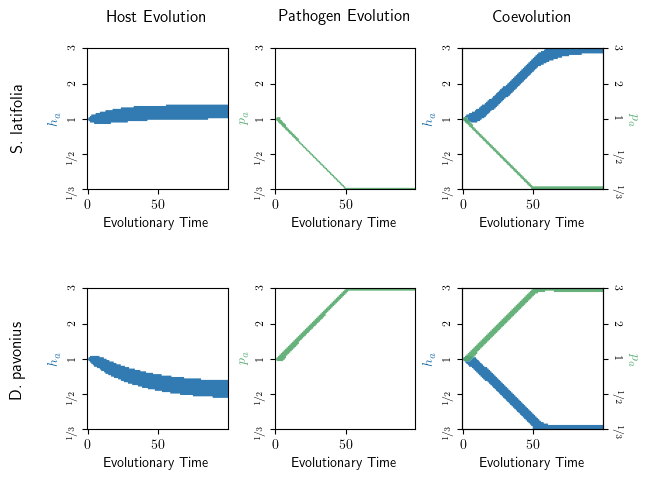

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=3, layout='constrained')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C1])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C2])

ax[0,0].annotate('S. latifolia', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')
ax[1,0].annotate('D. pavonius', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')

ax[0,0].set_title('Host Evolution', fontsize=12, pad=20)
ax[0,1].set_title('Pathogen Evolution', fontsize=12, pad=20)
ax[0,2].set_title('Coevolution', fontsize=12, pad=20)

img_Sa_lat_host, _, alpha_Sa_lat_host, _ = make_image(results_lat_host[1], results_lat_host[3])
_, img_Ia_lat_path, _, alpha_Ia_lat_path = make_image(results_lat_path[1], results_lat_path[3])
img_Sa_lat_coevol, img_Ia_lat_coevol, alpha_Sa_lat_coevol, alpha_Ia_lat_coevol = make_image(results_lat_coevol[1], results_lat_coevol[3])

img_Sa_pav_host, _, alpha_Sa_pav_host, _ = make_image(results_pav_host[1], results_pav_host[3])
_, img_Ia_pav_path, _, alpha_Ia_pav_path = make_image(results_pav_path[1], results_pav_path[3])
img_Sa_pav_coevol, img_Ia_pav_coevol, alpha_Sa_pav_coevol, alpha_Ia_pav_coevol = make_image(results_pav_coevol[1], results_pav_coevol[3])

ax[0,0].imshow(img_Sa_lat_host, alpha=alpha_Sa_lat_host, cmap=s_cmap)
ax[0,1].imshow(img_Ia_lat_path, alpha=alpha_Ia_lat_path, cmap=i_cmap)

ax[0,2].imshow(img_Sa_lat_coevol, alpha=alpha_Sa_lat_coevol, cmap=s_cmap)
ax[0,2].imshow(img_Ia_lat_coevol, alpha=alpha_Ia_lat_coevol, cmap=i_cmap)

ax[1,0].imshow(img_Sa_pav_host, alpha=alpha_Sa_pav_host, cmap=s_cmap)
ax[1,1].imshow(img_Ia_pav_path, alpha=alpha_Ia_pav_path, cmap=i_cmap)

ax[1,2].imshow(img_Sa_pav_coevol, alpha=alpha_Sa_pav_coevol, cmap=s_cmap)
ax[1,2].imshow(img_Ia_pav_coevol, alpha=alpha_Ia_pav_coevol, cmap=i_cmap)

ax[0,0].set_xlabel('Evolutionary Time', fontsize=10)
ax[0,1].set_xlabel('Evolutionary Time', fontsize=10)
ax[0,2].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,0].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,1].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,2].set_xlabel('Evolutionary Time', fontsize=10)


ax_tick_pos = np.linspace(ax[0,0].get_ylim()[0], ax[0,0].get_ylim()[1], 5)
ax_tick_labels = [r'$\sfrac{1}{3}$',r'$\sfrac{1}{2}$',r'$1$',r'$2$',r'$3$']


ax[0,0].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[0,0].set_ylabel(r'$h_a$', color=C1, fontsize=10)

ax[0,1].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[0,1].set_ylabel(r'$p_a$', color=C2, fontsize=10)

ax[0,2].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[0,2].set_ylabel(r'$h_a$', color=C1, fontsize=10)

twin_0 = ax[0,2].twinx()
twin_0.set_yticks(ax_tick_pos, reversed(ax_tick_labels), rotation=270, fontsize=8)
twin_0.set_ylabel(r'$p_a$', color=C2, rotation=270, fontsize=10, va='bottom')
twin_0.set_box_aspect(1)

ax[1,0].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[1,0].set_ylabel(r'$h_a$', color=C1, fontsize=10)

ax[1,1].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[1,1].set_ylabel(r'$p_a$', color=C2, fontsize=10)

ax[1,2].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90, fontsize=8)
ax[1,2].set_ylabel(r'$h_a$', color=C1, fontsize=10)

twin_0 = ax[1,2].twinx()
twin_0.set_yticks(ax_tick_pos, reversed(ax_tick_labels), rotation=270, fontsize=8)
twin_0.set_ylabel(r'$p_a$', color=C2, rotation=270, fontsize=10, va='bottom')
twin_0.set_box_aspect(1)



Text(0.5, 0, 'Evolutionary Time')

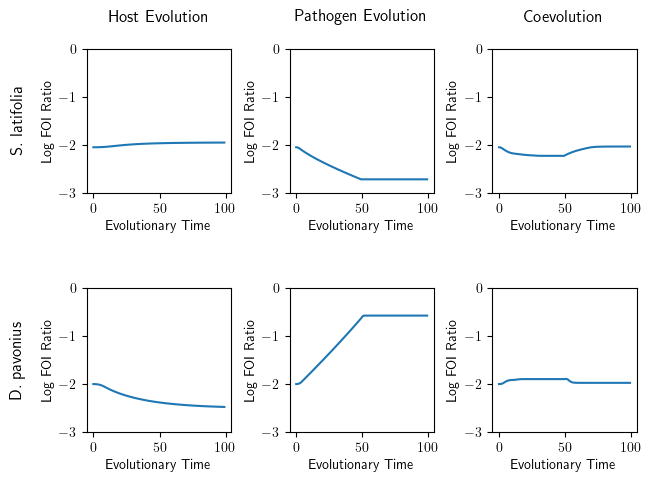

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=3, layout='constrained')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C1])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C2])

ax[0,0].annotate('S. latifolia', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')
ax[1,0].annotate('D. pavonius', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')

ax[0,0].set_title('Host Evolution', fontsize=12, pad=20)
ax[0,1].set_title('Pathogen Evolution', fontsize=12, pad=20)
ax[0,2].set_title('Coevolution', fontsize=12, pad=20)

ax[0,0].plot(transmission_ratio(lat_host, results_lat_host[0], results_lat_host[1], results_lat_host[2], results_lat_host[3]))
ax[0,1].plot(transmission_ratio(lat_path, results_lat_path[0], results_lat_path[1], results_lat_path[2], results_lat_path[3]))
ax[0,2].plot(transmission_ratio(lat_coevol, results_lat_coevol[0], results_lat_coevol[1], results_lat_coevol[2], results_lat_coevol[3]))
ax[1,0].plot(transmission_ratio(pav_host, results_pav_host[0], results_pav_host[1], results_pav_host[2], results_pav_host[3]))
ax[1,1].plot(transmission_ratio(pav_path, results_pav_path[0], results_pav_path[1], results_pav_path[2], results_pav_path[3]))
ax[1,2].plot(transmission_ratio(pav_coevol, results_pav_coevol[0], results_pav_coevol[1], results_pav_coevol[2], results_pav_coevol[3]))

ax[0,0].set_ylim(-3, 0)
ax[0,1].set_ylim(-3, 0)
ax[0,2].set_ylim(-3, 0)
ax[1,0].set_ylim(-3, 0)
ax[1,1].set_ylim(-3, 0)
ax[1,2].set_ylim(-3, 0)
matplotlib.rcParams["text.usetex"] = True
ax[0,0].set_ylabel('Log FOI Ratio', fontsize=10)
ax[0,1].set_ylabel('Log FOI Ratio', fontsize=10)
ax[0,2].set_ylabel('Log FOI Ratio', fontsize=10)
ax[1,0].set_ylabel('Log FOI Ratio', fontsize=10)
ax[1,1].set_ylabel('Log FOI Ratio', fontsize=10)
ax[1,2].set_ylabel('Log FOI Ratio', fontsize=10)

ax[0,0].set_box_aspect(1)
ax[0,1].set_box_aspect(1)
ax[0,2].set_box_aspect(1)
ax[1,0].set_box_aspect(1)
ax[1,1].set_box_aspect(1)
ax[1,2].set_box_aspect(1)

ax[0,0].set_xlabel('Evolutionary Time', fontsize=10)
ax[0,1].set_xlabel('Evolutionary Time', fontsize=10)
ax[0,2].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,0].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,1].set_xlabel('Evolutionary Time', fontsize=10)
ax[1,2].set_xlabel('Evolutionary Time', fontsize=10)

Text(0.5, 0, 'Evolutionary Time')

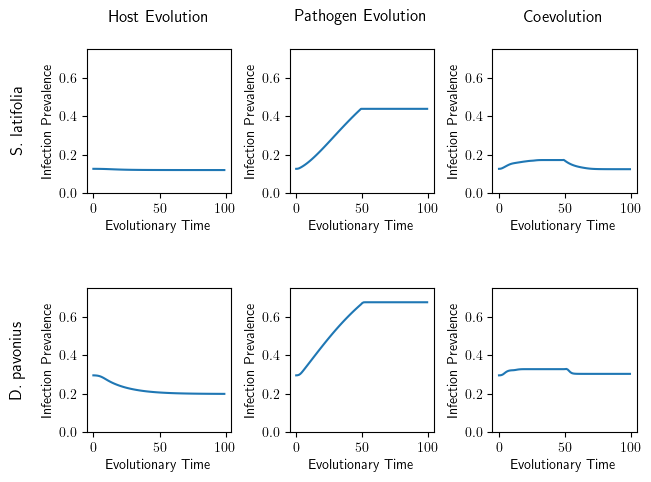

In [13]:
fig, ax = plt.subplots(nrows=2, ncols=3, layout='constrained')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C1])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white",C2])

ax[0,0].annotate('S. latifolia', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')
ax[1,0].annotate('D. pavonius', xy=(0, 0.5), xytext=(-50,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=12, style='italic')

ax[0,0].set_title('Host Evolution', fontsize=12, pad=20)
ax[0,1].set_title('Pathogen Evolution', fontsize=12, pad=20)
ax[0,2].set_title('Coevolution', fontsize=12, pad=20)

def prevalence(results):
    N = np.sum(results[0] + results[1] + results[2] + results[3], axis=0)

    infected = np.sum(results[2] + results[3], axis=0)

    return infected / N
                      
ax[0,0].plot(prevalence(results_lat_host))
ax[0,1].plot(prevalence(results_lat_path))
ax[0,2].plot(prevalence(results_lat_coevol))
ax[1,0].plot(prevalence(results_pav_host))
ax[1,1].plot(prevalence(results_pav_path))
ax[1,2].plot(prevalence(results_pav_coevol))

ax[0,0].set_ylim(0, 0.75)
ax[0,1].set_ylim(0, 0.75)
ax[0,2].set_ylim(0, 0.75)
ax[1,0].set_ylim(0, 0.75)
ax[1,1].set_ylim(0, 0.75)
ax[1,2].set_ylim(0, 0.75)

ax[0,0].set_box_aspect(1)
ax[0,1].set_box_aspect(1)
ax[0,2].set_box_aspect(1)
ax[1,0].set_box_aspect(1)
ax[1,1].set_box_aspect(1)
ax[1,2].set_box_aspect(1)

ax[0,0].set_ylabel('Infection Prevalence', fontsize=10)
ax[0,1].set_ylabel('Infection Prevalence', fontsize=10)
ax[0,2].set_ylabel('Infection Prevalence', fontsize=10)
ax[1,0].set_ylabel('Infection Prevalence', fontsize=10)
ax[1,1].set_ylabel('Infection Prevalence', fontsize=10)
ax[1,2].set_ylabel('Infection Prevalence', fontsize=10)

ax[0,0].set_xlabel('Evolutionary Time')
ax[0,1].set_xlabel('Evolutionary Time')
ax[0,2].set_xlabel('Evolutionary Time')
ax[1,0].set_xlabel('Evolutionary Time')
ax[1,1].set_xlabel('Evolutionary Time')
ax[1,2].set_xlabel('Evolutionary Time')